In [5]:
import pandas as pd

df_24 = pd.read_csv("/content/final-supplemental-24hrs.csv", low_memory=False)

metric_cols = [
    "public_metrics.like_count",
    "public_metrics.retweet_count",
    "public_metrics.reply_count",
    "public_metrics.quote_count",
]

for c in metric_cols:
    if c not in df_24.columns:
        df_24[c] = 0

df_24["total_engagement"] = df_24[metric_cols].fillna(0).sum(axis=1)

df_24.head()


,id,text,referenced_tweets,edit_history_tweet_ids,possibly_sensitive,reply_settings,lang,created_at,conversation_id,author_id,...,location,name,username,brand,entities.hashtags,withheld.country_codes,geo.place_id,entities.cashtags,attachments.poll_ids,total_engagement
0,2021060799096291371,RT @JRho_11: Dumbass nigga @druski,"[{'type': 'retweeted', 'id': '2020935293340352...",['2021060799096291371'],False,everyone,en,2026-02-10T03:16:58.000Z,2021060799096291371,1390484692286132226,...,"East Oakland, California","Hustle Chillson, 1st of his name",HustelChillson,T-Mobile_1,NaN,NaN,NaN,NaN,NaN,512
1,2021060709661233548,RT @backstreetboys: Good luck getting our Supe...,"[{'type': 'retweeted', 'id': '2020949188062625...",['2021060709661233548'],False,everyone,en,2026-02-10T03:16:37.000Z,2021060709661233548,247081737,...,Guadalajara,Tannia Carter 🌐,TanniaCarterBSB,T-Mobile_1,NaN,NaN,NaN,NaN,NaN,198
2,2021060683761344887,RT @mgkmagic: mgk on performing at the pre-Gra...,"[{'type': 'retweeted', 'id': '2018007497479692...",['2021060683761344887'],False,everyone,en,2026-02-10T03:16:31.000Z,2021060683761344887,1408469944338206721,...,"City of Swansea, Wales, UK",metal princess the one and only,juliewi50263850,T-Mobile_1,NaN,NaN,NaN,NaN,NaN,26
3,2021060592313008253,"RT @MarshaBlackburn: Tomorrow, I will lead the...","[{'type': 'retweeted', 'id': '2021015070604689...",['2021060592313008253'],False,everyone,en,2026-02-10T03:16:09.000Z,2021060592313008253,2006379060406935552,...,NaN,Nico Piccolo,Crusher1367,T-Mobile_1,NaN,NaN,NaN,NaN,NaN,3056
4,2021060493843235072,"RT @MarshaBlackburn: Tomorrow, I will lead the...","[{'type': 'retweeted', 'id': '2021015070604689...",['2021060493843235072'],False,everyone,en,2026-02-10T03:15:45.000Z,2021060493843235072,2019460648522973184,...,NaN,Kevin Cardogno,K68yxpw4p44,T-Mobile_1,NaN,NaN,NaN,NaN,NaN,3056


In [6]:
brand_24_summary = df_24.groupby("brand").agg(
    tweet_volume=("id", "count"),
    total_engagement=("total_engagement", "sum"),
    mean_engagement=("total_engagement", "mean"),
)

brand_24_summary["engagement_per_tweet"] = (
    brand_24_summary["total_engagement"] /
    brand_24_summary["tweet_volume"]
)

brand_24_summary.sort_values("total_engagement", ascending=False).head(15)


,tweet_volume,total_engagement,mean_engagement,engagement_per_tweet
brand,,,,
Blue Square Alliance Against Hate_1,1747,15812985,9051.508300,9051.508300
DraftKings_1,5773,8802912,1524.841850,1524.841850
Toyota_1,4082,8680354,2126.495345,2126.495345
Ro_1,3438,4381629,1274.470332,1274.470332
Levi’s_1,861,3868353,4492.860627,4492.860627
NFL_1,2827,3297650,1166.483905,1166.483905
Lay’s_1,1137,2170793,1909.228672,1909.228672
Liquid Death_1,615,1513756,2461.391870,2461.391870
State Farm_1,738,1169768,1585.051491,1585.051491


In [4]:
brand_24_filtered = brand_24_summary[
    brand_24_summary["tweet_volume"] >= 20
].copy()

brand_24_filtered.sort_values("total_engagement", ascending=False).head(10)


,tweet_volume,total_engagement,mean_engagement,engagement_per_tweet
brand,,,,
Blue Square Alliance Against Hate_1,1747,15812985,9051.508300,9051.508300
DraftKings_1,5773,8802912,1524.841850,1524.841850
Toyota_1,4082,8680354,2126.495345,2126.495345
Ro_1,3438,4381629,1274.470332,1274.470332
Levi’s_1,861,3868353,4492.860627,4492.860627
NFL_1,2827,3297650,1166.483905,1166.483905
Lay’s_1,1137,2170793,1909.228672,1909.228672
Liquid Death_1,615,1513756,2461.391870,2461.391870
State Farm_1,738,1169768,1585.051491,1585.051491


In [8]:
import pandas as pd
import matplotlib.pyplot as plt


df_24 = pd.read_csv("/content/final-supplemental-24hrs.csv", low_memory=False)

metric_cols = [
    "public_metrics.like_count",
    "public_metrics.retweet_count",
    "public_metrics.reply_count",
    "public_metrics.quote_count",
]

for c in metric_cols:
    if c not in df_24.columns:
        df_24[c] = 0

df_24["total_engagement"] = df_24[metric_cols].fillna(0).sum(axis=1)

brand_24 = df_24.groupby("brand").agg(
    tweet_volume=("id", "count"),
    total_engagement=("total_engagement", "sum"),
).copy()

brand_24["engagement_per_tweet"] = brand_24["total_engagement"] / brand_24["tweet_volume"]

min_tweets = 20
brand_24_f = brand_24[brand_24["tweet_volume"] >= min_tweets].copy()

brand_24_f.head()


,tweet_volume,total_engagement,engagement_per_tweet
brand,,,
Base44_1,100,266,2.660000
Blue Square Alliance Against Hate_1,1747,15812985,9051.508300
Boehringer Ingelheim_1,99,8416,85.010101
Bosch_1,100,2283,22.830000
Bud Light_1,100,124087,1240.870000


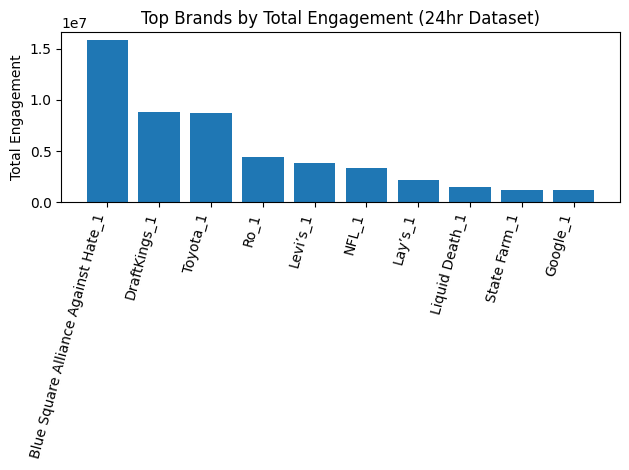

In [9]:
top_n = 10

top_eng = brand_24_f.sort_values("total_engagement", ascending=False).head(top_n)

plt.figure()
plt.bar(top_eng.index, top_eng["total_engagement"])
plt.xticks(rotation=75, ha="right")
plt.title("Top Brands by Total Engagement (24hr Dataset)")
plt.ylabel("Total Engagement")
plt.tight_layout()
plt.show()


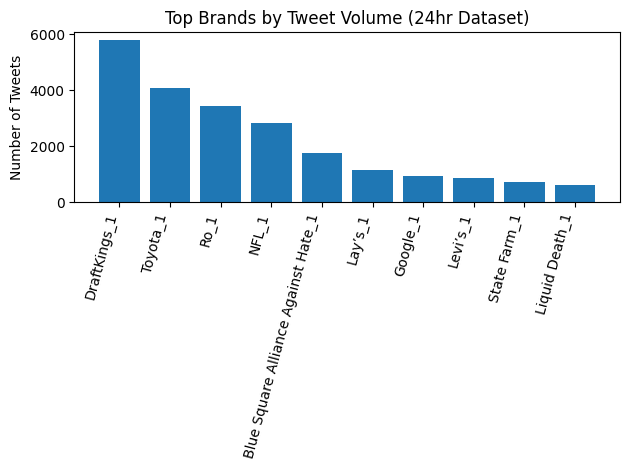

In [10]:
top_vol = brand_24_f.sort_values("tweet_volume", ascending=False).head(top_n)

plt.figure()
plt.bar(top_vol.index, top_vol["tweet_volume"])
plt.xticks(rotation=75, ha="right")
plt.title("Top Brands by Tweet Volume (24hr Dataset)")
plt.ylabel("Number of Tweets")
plt.tight_layout()
plt.show()


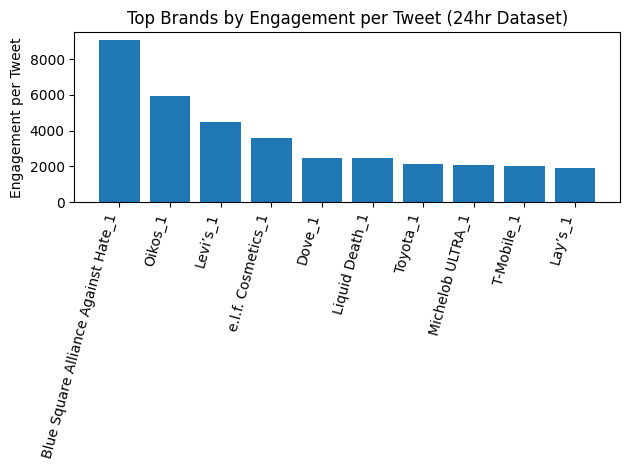

In [11]:
top_eff = brand_24_f.sort_values("engagement_per_tweet", ascending=False).head(top_n)

plt.figure()
plt.bar(top_eff.index, top_eff["engagement_per_tweet"])
plt.xticks(rotation=75, ha="right")
plt.title("Top Brands by Engagement per Tweet (24hr Dataset)")
plt.ylabel("Engagement per Tweet")
plt.tight_layout()
plt.show()


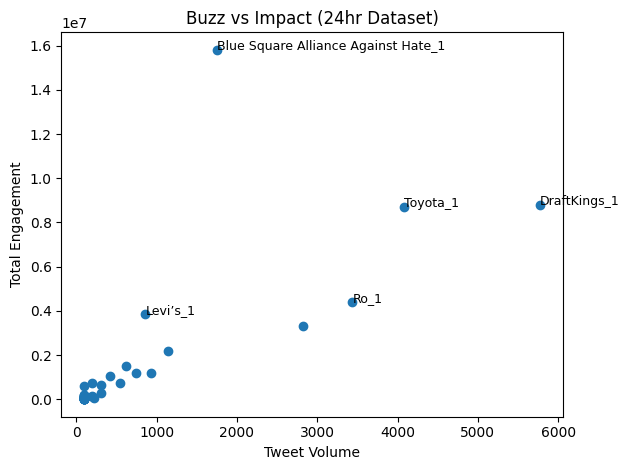

In [15]:
import matplotlib.pyplot as plt

top5 = brand_24.sort_values("total_engagement", ascending=False).head(5)

plt.figure()

plt.scatter(
    brand_24["tweet_volume"],
    brand_24["total_engagement"]
)

for brand, row in top5.iterrows():
    plt.text(
        row["tweet_volume"],
        row["total_engagement"],
        brand,
        fontsize=9
    )

plt.xlabel("Tweet Volume")
plt.ylabel("Total Engagement")
plt.title("Buzz vs Impact (24hr Dataset)")
plt.tight_layout()
plt.show()


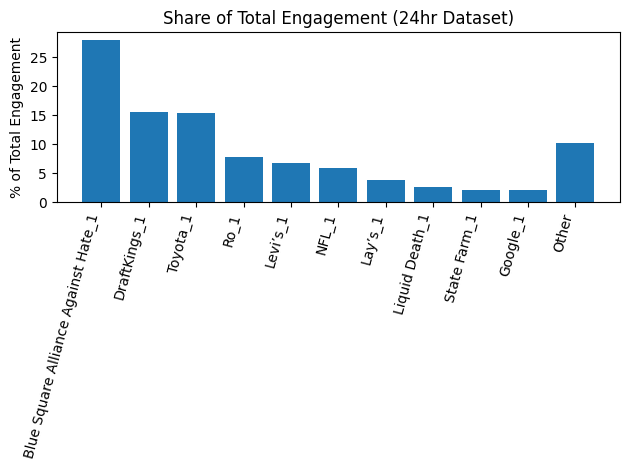

In [14]:
total_eng_all = brand_24["total_engagement"].sum()

share = (brand_24["total_engagement"] / total_eng_all).sort_values(ascending=False)

top_share = share.head(10)
other_share = share.iloc[10:].sum()

share_plot = pd.concat([top_share, pd.Series({"Other": other_share})])

plt.figure()
plt.bar(share_plot.index, share_plot.values * 100)
plt.xticks(rotation=75, ha="right")
plt.title("Share of Total Engagement (24hr Dataset)")
plt.ylabel("% of Total Engagement")
plt.tight_layout()
plt.show()


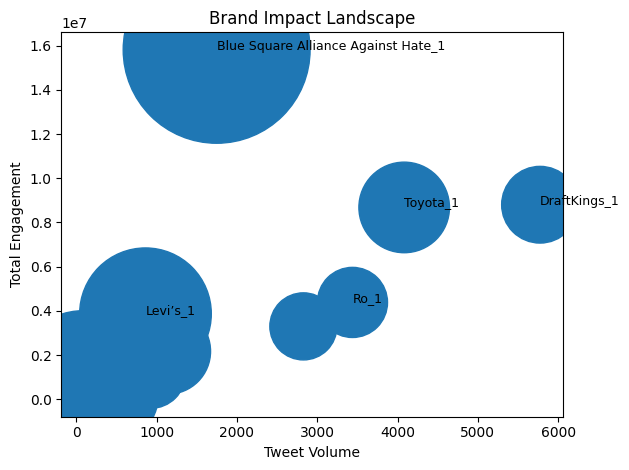

In [21]:
top5 = brand_24.sort_values("total_engagement", ascending=False).head(5)

plt.figure()

plt.scatter(
    brand_24["tweet_volume"],
    brand_24["total_engagement"],
    s=brand_24["engagement_per_tweet"] * 2
)

for brand, row in top5.iterrows():
    plt.text(
        row["tweet_volume"],
        row["total_engagement"],
        brand,
        fontsize=9
    )

plt.xlabel("Tweet Volume")
plt.ylabel("Total Engagement")
plt.title("Brand Impact Landscape")

plt.tight_layout()
plt.show()
